#**Домашнее задание №3**
##**Выполнила:** Шумилова Мария Константиновна 409920 U3310
##**Проверила:** Желтова Кристина Анатольевна

## **Загрузка данных**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_style("whitegrid")

# export KAGGLE_API_TOKEN=KGAT_e32f1e27c3076e0083f2ef1a7904bc58
%pip install opendatasets -q
import opendatasets as od

od.download("https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/data")

csv_files = glob.glob("ibm-hr-analytics-attrition-dataset/*.csv")

df = pd.read_csv(csv_files[0])

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bulk2403
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


100%|██████████| 50.1k/50.1k [00:00<00:00, 42.7MB/s]

### *random_state*

In [2]:
import random
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## **1. Построение модели**

### **1.1 Разбиение выборки на обучающую и тестовую**

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

drop_cols = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]

X = df.drop(columns=["Attrition"] + drop_cols)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

Сначала из датасета удаляются признаки, которые не несут полезной информации для предсказания. К ним относятся идентификаторы и признаки с почти постоянными значениями, так как они не помогают модели находить закономерности.
Также мы разделили выборку на тренировочную и тестовую в соотношении 80/20

### **1.2 Подготовка признаков**

In [5]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="passthrough"
)

В этом блоке кода признаки разделяются на числовые и категориальные.

Для категориальных признаков применяется кодирование с помощью `OneHotEncoder`, чтобы преобразовать их в числовой формат. Числовые признаки при этом остаются без изменений.

Все преобразования объединяются с помощью `ColumnTransformer`, что позволяет удобно применять их в дальнейшем внутри пайплайна модели.

### **1.3 Подбор гиперпараметров Random Forest**

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf),
    ]
)

recall_yes_scorer = make_scorer(recall_score, pos_label="Yes")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": [None, "balanced"],
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=recall_yes_scorer,  # теперь правильно
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)

print("Лучшие гиперпараметры:")
print(random_search.best_params_)

print("\nЛучшее значение recall на кросс-валидации:")
print(round(random_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие гиперпараметры:
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 5, 'model__class_weight': 'balanced'}

Лучшее значение recall на кросс-валидации:
0.4368


Random Forest был выбран как модель для решения задачи, так как он хорошо работает с табличными данными, учитывает нелинейные зависимости и устойчив к переобучению благодаря усреднению предсказаний множества деревьев. Кроме того, он не требует сложной предобработки и способен обрабатывать как числовые, так и категориальные признаки после кодирования, что делает его удобным и надёжным выбором для данной задачи классификации.

В результате подбора гиперпараметров с использованием кросс-валидации была получена модель со следующими параметрами: ограниченная глубина деревьев, увеличенные значения минимального числа объектов в узлах и использование балансировки классов.

Лучшее значение recall на кросс-валидации составило около 0.44. Это означает, что модель способна выявить примерно 44% сотрудников, которые действительно склонны к увольнению.

Полученные гиперпараметры указывают на то, что модель стремится избежать переобучения: небольшая глубина деревьев и ограничения на разбиения делают модель более устойчивой и обобщающей. Использование параметра class_weight="balanced" позволяет учитывать дисбаланс классов и повышает способность модели находить редкий класс Attrition = Yes.

В целом результат можно считать удовлетворительным, учитывая сложность задачи и дисбаланс классов.

### **1.4 Обучение модели и оценка**

Recall на тестовой выборке: 0.5319

Classification report:
              precision    recall  f1-score   support

          No       0.91      0.87      0.89       247
         Yes       0.43      0.53      0.48        47

    accuracy                           0.81       294
   macro avg       0.67      0.70      0.68       294
weighted avg       0.83      0.81      0.82       294



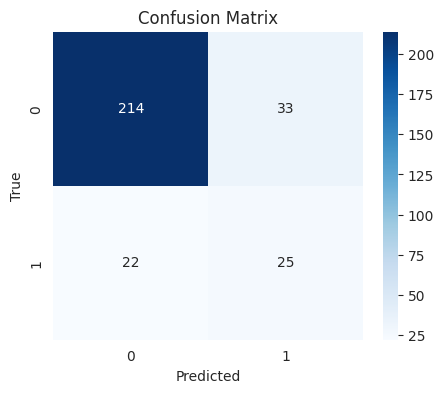

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

test_recall = recall_score(y_test, y_pred, pos_label="Yes")
print("Recall на тестовой выборке:", round(test_recall, 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["No", "Yes"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

На отложенной тестовой выборке модель показала recall для класса Attrition = Yes, равный 0.5319. Это означает, что модель смогла правильно выявить около 53% сотрудников, которые действительно склонны к увольнению. Для данной задачи это является достаточно важным результатом, так как основная цель заключалась именно в том, чтобы не пропускать потенциально уходящих сотрудников.

По классификационному отчету видно, что для класса Yes precision составляет 0.43, а F1-score — 0.48. Это говорит о том, что модель находит часть сотрудников группы риска, но при этом делает и заметное число ложных срабатываний. Для класса No качество заметно выше: precision = 0.91, recall = 0.87, F1-score = 0.89. Общая accuracy модели составляет 0.81, однако в данной задаче эта метрика не является основной, так как данные несбалансированы, и более важным является качество распознавания редкого класса.

Матрица ошибок подтверждает этот вывод: модель правильно классифицировала 214 сотрудников как не планирующих увольнение и 25 сотрудников как относящихся к классу Yes, но при этом пропустила 22 реальных случая увольнения и 33 раза ошибочно предсказала увольнение там, где его не было. В целом модель можно считать полезной, так как она достаточно хорошо справляется с поиском сотрудников группы риска, хотя баланс между recall и precision для положительного класса еще можно улучшать.

## **2. Интерпретация**

### **2.1 Глобальная интерпретация модели: permutation importance**

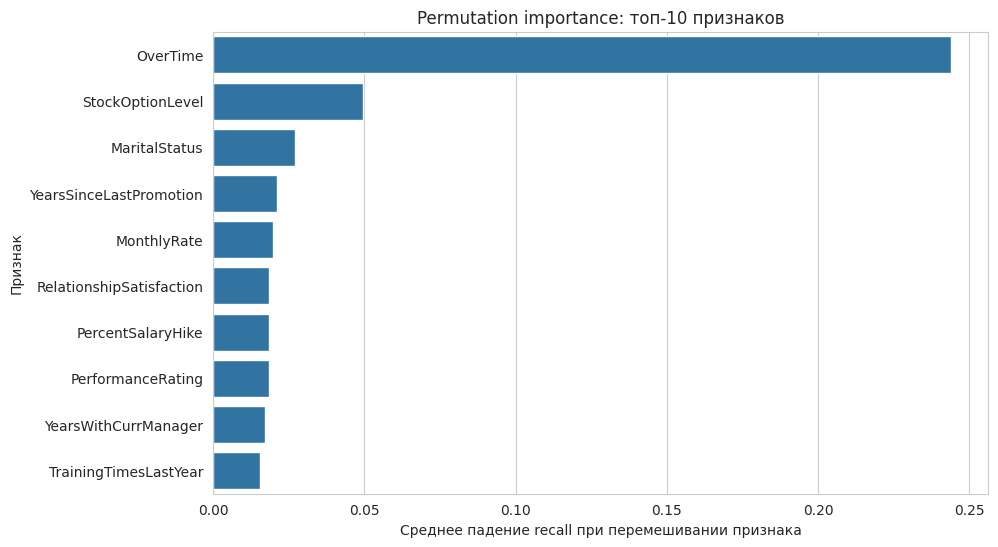

,feature,importance,std
18,OverTime,0.243972,0.044540
22,StockOptionLevel,0.049645,0.027650
14,MaritalStatus,0.026950,0.021229
28,YearsSinceLastPromotion,0.021277,0.000000
16,MonthlyRate,0.019858,0.005307
21,RelationshipSatisfaction,0.018440,0.007233
19,PercentSalaryHike,0.018440,0.007233
20,PerformanceRating,0.018440,0.007233
29,YearsWithCurrManager,0.017021,0.022247
24,TrainingTimesLastYear,0.015603,0.009409


In [11]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score, make_scorer

recall_yes_scorer = make_scorer(recall_score, pos_label="Yes")

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=RANDOM_STATE,
    scoring=recall_yes_scorer,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature"
)
plt.title("Permutation importance: топ-10 признаков")
plt.xlabel("Среднее падение recall при перемешивании признака")
plt.ylabel("Признак")
plt.show()

importance_df.head(10)

### 2.1 Глобальная интерпретация модели

В этом блоке кода я выполнила глобальную интерпретацию модели с помощью метода permutation importance. Сначала был задан scorer по метрике recall для класса `Yes`, потому что для задачи оттока важно не пропускать сотрудников, которые действительно собираются уйти. Затем для каждого признака по очереди происходило случайное перемешивание значений на тестовой выборке, и после этого измерялось, насколько снижалось качество модели. Чем сильнее падал recall, тем более важным считался признак.

В результате работы кода был построен график топ-10 наиболее важных признаков и таблица с их вкладом. Наибольшую значимость демонстрирует признак OverTime (важность `0.244`, std `0.045`), что указывает на его критическую роль в определении риска ухода: при искажении информации о переработках recall падает почти на четверть.

Остальные признаки оказывают значительно меньшее влияние. Выделяются StockOptionLevel (`0.050`), MaritalStatus (`0.027`) и YearsSinceLastPromotion (`0.021`). Группа признаков, включающая MonthlyRate, RelationshipSatisfaction, PercentSalaryHike и PerformanceRating, имеет близкие значения важности около `0.018–0.020`. Сравнительно высокие стандартные отклонения (например, у `YearsWithCurrManager` – `0.022` при важности `0.017`) свидетельствуют о некоторой вариабельности оценки значимости этих признаков на разных итерациях перестановок. Таким образом, с точки зрения способности модели правильно идентифицировать увольняющихся сотрудников, наличие сверхурочной работы является доминирующим фактором, в то время как прочие характеристики вносят умеренный и сопоставимый по величине вклад.

### **2.2 Локальная интерпретация: SHAP для отдельных объектов**

Объект с наибольшей вероятностью Attrition = Yes


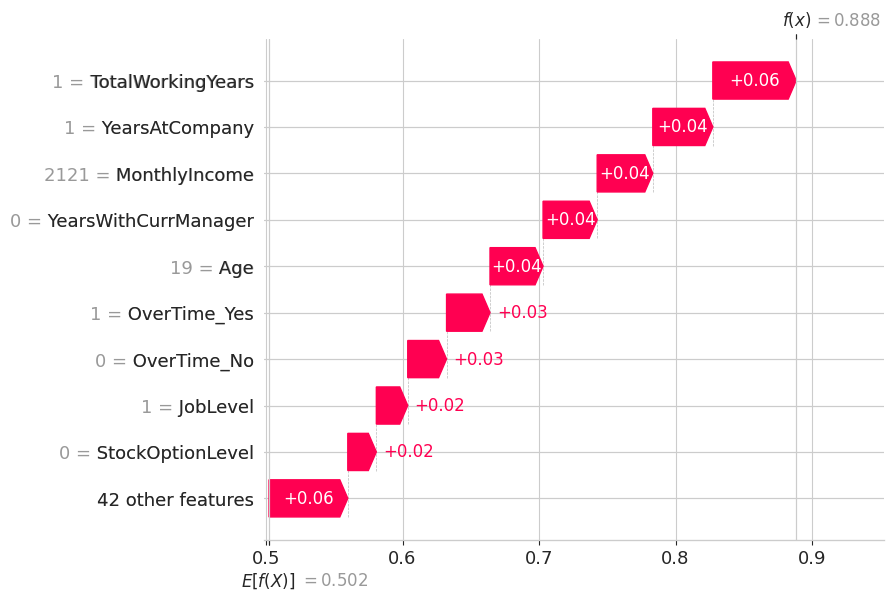

Объект с наименьшей вероятностью Attrition = Yes


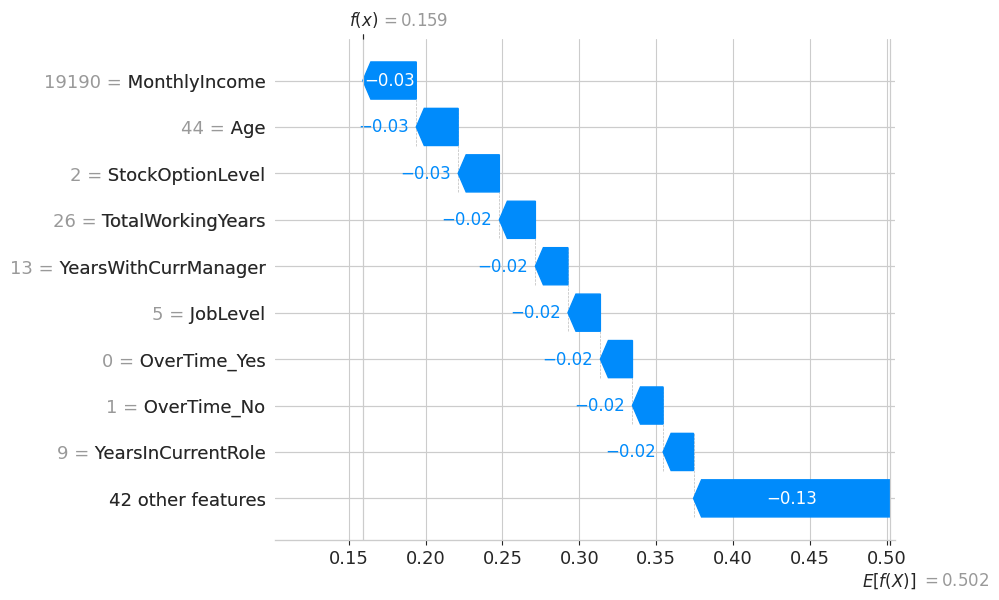

In [13]:
import shap

# Достаём шаги пайплайна
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

# Преобразуем тестовую выборку
X_test_transformed = preprocessor.transform(X_test)

# Если матрица разреженная, переводим в обычный массив
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Получаем имена признаков после кодирования
cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = list(cat_names) + numeric_features

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# Обработка разных форматов SHAP
if isinstance(shap_values, list):
    shap_values_yes = shap_values[1]
    base_value = explainer.expected_value[1]
elif len(shap_values.shape) == 3:
    class_index = list(best_model.classes_).index("Yes")
    shap_values_yes = shap_values[:, :, class_index]
    base_value = explainer.expected_value[class_index]
else:
    shap_values_yes = shap_values
    base_value = explainer.expected_value

# Вероятности для класса Yes
proba_yes = best_model.predict_proba(X_test)[:, list(best_model.classes_).index("Yes")]

# Индексы объектов
idx_high = int(np.argmax(proba_yes))
idx_low = int(np.argmin(proba_yes))

# Визуализация
for idx, title in [
    (idx_high, "Объект с наибольшей вероятностью Attrition = Yes"),
    (idx_low, "Объект с наименьшей вероятностью Attrition = Yes")
]:
    print(title)

    exp = shap.Explanation(
        values=shap_values_yes[idx],
        base_values=base_value,
        data=X_test_transformed[idx],
        feature_names=feature_names
    )

    shap.plots.waterfall(exp, max_display=10)

В этом блоке кода я выполнила локальную интерпретацию предсказаний с помощью SHAP. Сначала были извлечены шаги пайплайна: препроцессор и обученная модель. Затем тестовая выборка была преобразована в тот вид, в котором она подаётся в модель, а для закодированных категориальных признаков были получены новые названия. После этого был создан `TreeExplainer`, который позволяет оценить вклад каждого признака в конкретное предсказание. Далее были построенны две диаграммы типа waterfall для того, чтобы показать вклад отдельных признаков в предсказание модели для конкретных сотрудников.

**Объект с высокой вероятностью Attrition = Yes**

Наибольшее увеличение вероятности связано с малым общим стажем работы (`TotalWorkingYears = 1`, вклад `+0.06`), низким ежемесячным доходом (`MonthlyIncome = 2121`, `+0.04`), небольшим стажем в компании (`YearsAtCompany = 1`, `+0.04`), отсутствием опыта взаимодействия с текущим руководителем (`YearsWithCurrManager = 0`, `+0.04`) и молодым возрастом (`Age = 19`, `+0.04`). Дополнительный повышающий эффект оказывают наличие сверхурочной работы (`OverTime_Yes`, `+0.03`), низкий должностной уровень (`JobLevel = 1`, `+0.02`) и отсутствие опционов на акции (`StockOptionLevel = 0`, `+0.02`). Группа из 42 прочих признаков также даёт суммарный положительный вклад `+0.06`.

**Объект с низкой вероятностью Attrition = Yes**

Наибольшее снижение вероятности (`-0.13`) связано с отсутствованием переработок (`OverTime_No`). Это указывает на то, что нормализованный график работы является существенным фактором удержания.

Дополнительное понижающее воздействие оказывают высокий уровень ежемесячного дохода (`MonthlyIncome = 19190`), возраст (`Age = 44`) и значительный общий стаж работы (`TotalWorkingYears = 26`). Меньший, но также направленный на снижение риска вклад вносят длительное пребывание в текущей должности (`YearsInCurrentRole = 9`), продолжительная работа под руководством одного менеджера (`YearsWithCurrManager = 13`), высокий должностной уровень (`JobLevel = 5`) и наличие опционов на акции (`StockOptionLevel = 2`). Суммарное влияние перечисленных и 42 других признаков формирует низкую результирующую вероятность ухода, равную `0.159`.

### **2.3 Общее мнение о полученной интерпретации**

В целом полученная интерпретация выглядит логичной и хорошо согласуется с предметной областью: модель опирается на такие признаки, как переработки, уровень дохода, стаж и карьерное развитие, которые действительно влияют на вероятность увольнения сотрудников. Это позволяет сделать вывод, что модель улавливает осмысленные закономерности в данных и принимает достаточно обоснованные решения, а не ориентируется на случайные зависимости.